In [3]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2

# Notebook uses functions from .py scripts in scripts/ folder
sys.path.append('../../scripts/coordinates_analysis')

from load import load_samples
from compare import compare_samples
from save import save_overlaps

# Compare peaks from different samples
This notebook finds overlaps between multiple BED files and:

1) Produce new BED files with different set of overlapping peaks (description of output is in "Save compared peaks" part);

2) Venn diagram;

Useful for comparing peaks from different experiments to identify common and unique regions.

#### Provide arguments - output directory and pathes to .bed files to compare

In [52]:
output_dir = '../../results/compared_peaks'

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############

sample1_path = '../../resources/MCM_G1.bed'
sample2_path = '../../resources/ARS_SGD.bed'
#sample3_path = '../../../ChEC_Data_Complete/homer_peaks_merged/RDY342_G1_nTr_nT_nC.bed'
#sample4_path =

include_neighbours = 0
# provide distance in bp from ending points to increase region of searching. If compared sample within this region, it's consider overlapping.
# include_neighbours = 0 will find only strict overlapping intervals

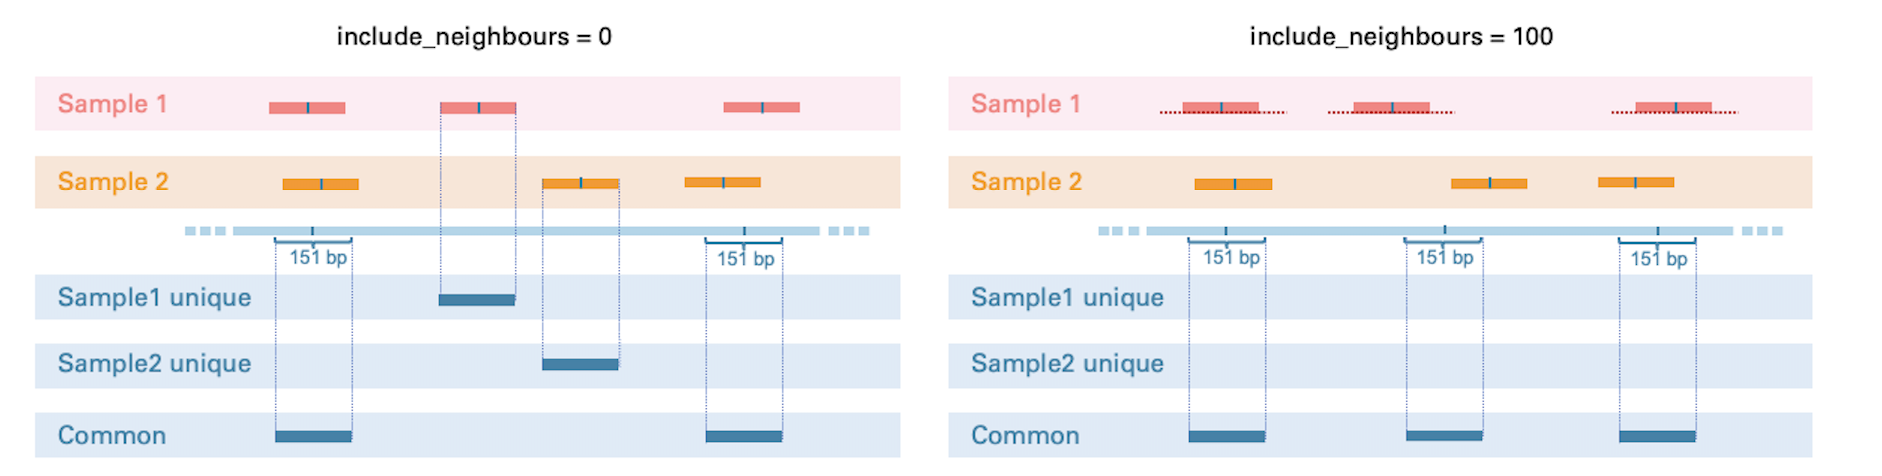

#### Run comparison

In [53]:
# For 2 samples
samples = load_samples(sample1_path, sample2_path)

# For 3 samples
#samples = load_samples(sample1_path, sample2_path, sample3_path)

# For 4 samples
#samples = load_samples(sample1_path, sample2_path, sample3_path, sample4_path)

overlaps_df = compare_samples(samples, include_neighbours=include_neighbours)

#### Save compared peaks to output_directory

In [54]:
# save_overlaps() saves .bed files and returns subdirectory where files are saved
output_subdir = save_overlaps(overlaps_df, output_dir)

#### Description of output .bed files

   output_dir/

            └── sample1_sample2
               ├── in_sample1_ex_sample2.bed -  unique peaks for sample1, excluding common peaks with sample2
               ├── in_sample2_ex_sample1.bed -  unique peaks for sample2, excluding common peaks with sample1
               └── in_sample1_sample2_ex.bed -  common peaks for both sample1 and sample2. NOTE: Common peaks are merged by centers.

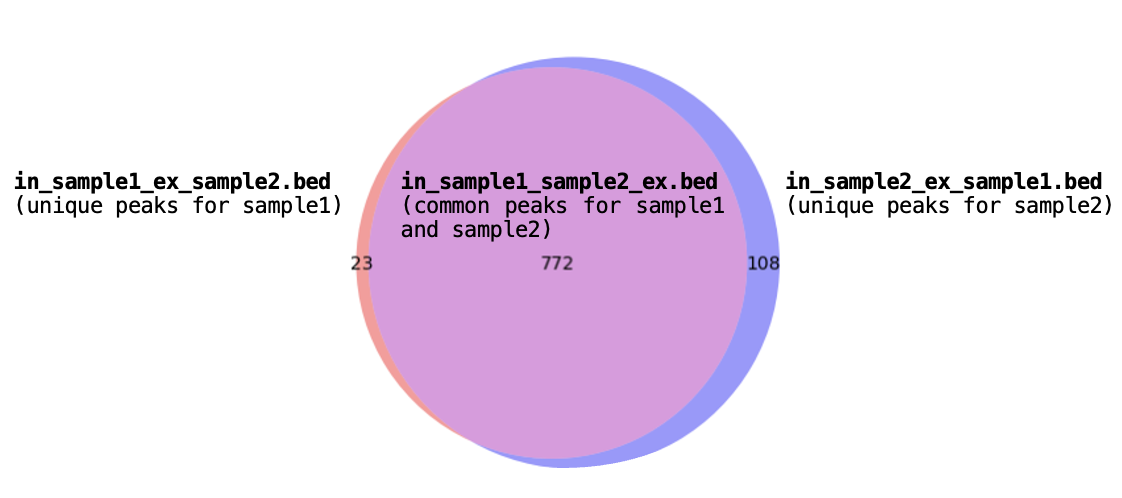

#### Plot venn diagram (for 2 or 3 samples)

In [ ]:
def plot_venn_diagram(overlaps_df, output_subdir):
    '''Plot venn diagram for 2 or 3 samples
    '''
    df_binary =  overlaps_df.iloc[:, 4:]
    sets = [set(np.argwhere(v).ravel()) for _,v in df_binary.items()]
    labels = [l.replace('.bed','') for l in df_binary.columns] # labels are files names, however you can change it
    #labels = ['MCM G1', 'ARS SGD'] # example if you want to change names on diagram
    # labels = [] # venn without labels
    if len(sets) == 2:
        venn2(sets, labels, set_colors=("magenta","green")) # HERE CHANGE COLORS 
    elif len(sets) == 3:
        venn3(sets, labels) # HERE CHANGE COLORS 
    else:
        print(f"Warning: Venn diagram for {len(sets)} sets not supported. Using first 3 columns.")
        venn3(sets[:3], set_labels=labels[:3])
    
    plt.savefig(os.path.join(output_subdir, "venn_diagram.png"), dpi=300, bbox_inches='tight')

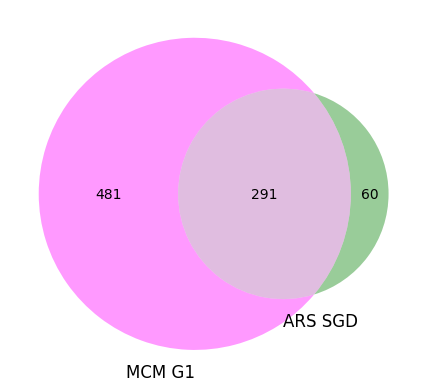

In [56]:
plot_venn_diagram(overlaps_df, output_subdir)